# Stochastic Gradient Descent for Higher Yeild

We want to minimize the impact of the fabrication variations to our final design, and hence increase the yield. We use the same fabrication variation as the 'sensitivity' notebook.

- etch depth (the partial etch goes too far down) $\sim\mathcal{N}(0,5nm)$
- Ovet/underetched (the teeth are too large or small) $\sim\mathcal{N}(0,5nm)$

To do this we will use stochastic gradient decent, sample the noise on the structure on each iteration. The Adam optimizer is well suited for this, so we only need to change the objective function.

In [9]:
import autograd.numpy as np 
import matplotlib.pyplot as plt

import tidy3d as td
import tidy3d.web as web
td.config.logging_level = "ERROR"

import pickle

from main import (make_sim, get_coupling_efficiency, projection_builder, run_adam, apodized_to_widths,
                    R, r0, initial_fill_factor, grating_period, 
                    etch_depth, to_substrate, N_teeth, n_wl, wl_range,
                    to_substrate)


We set up the new objective fucntion

In [10]:
# set up random number generator
sigmas = [.005,.005]
rng = np.random.default_rng(seed=42)

# define the objective function
def objective(params,projection=None):
    params_proj = projection(params)
    samples = rng.standard_normal(size=(len(sigmas))) * sigmas
    
    widths = params_proj[:-3]
    r0 = params_proj[N_teeth*2+2]
    etch_depth = params_proj[N_teeth*2+3] + samples[0]
    to_substrate = params_proj[N_teeth*2+4]
    
    sim = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, dilation=samples[1])
    sim_data = web.run(sim, task_name="GC4um_2D_stochastic_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")
    coupling_efficiency = get_coupling_efficiency(sim_data)
    return np.mean(coupling_efficiency)

Now we run the optimization, it looks very similar to the previous optimization since all the change is in the objective fucntion.

In [11]:
# define the initial parameters
widths = apodized_to_widths(R=R, initial_fill_factor=initial_fill_factor, N_teeth=N_teeth, grating_period=grating_period)
params0 = np.concatenate([widths, [r0], [etch_depth], [to_substrate]])

# define the projection for enforcing constraints
project, inverse_project = projection_builder()

# run the optimization
history, opt_state = run_adam(params0, project, inverse_project, objective, num_steps=35, learning_rate=0.01, verbose=True)

step = 1
	J = 4.117e-01
	grad_norm = 4.4531e-01
step = 2
	J = 3.174e-01
	grad_norm = 4.2313e-01
step = 3
	J = 3.660e-01
	grad_norm = 5.2486e-01
step = 4
	J = 3.955e-01
	grad_norm = 4.4433e-01
step = 5
	J = 4.256e-01
	grad_norm = 4.3445e-01
step = 6
	J = 3.774e-01
	grad_norm = 4.1079e-01
step = 7
	J = 3.450e-01
	grad_norm = 4.2561e-01
step = 8
	J = 4.664e-01
	grad_norm = 3.9599e-01
step = 9
	J = 4.781e-01
	grad_norm = 3.9407e-01
step = 10
	J = 4.550e-01
	grad_norm = 3.9607e-01
step = 11
	J = 4.730e-01
	grad_norm = 4.1497e-01
step = 12
	J = 4.913e-01
	grad_norm = 3.9376e-01
step = 13
	J = 4.710e-01
	grad_norm = 4.6275e-01
step = 14
	J = 4.701e-01
	grad_norm = 4.4259e-01
step = 15
	J = 4.709e-01
	grad_norm = 4.4282e-01
step = 16
	J = 5.441e-01
	grad_norm = 4.0222e-01
step = 17
	J = 5.230e-01
	grad_norm = 4.4071e-01
step = 18
	J = 4.641e-01
	grad_norm = 4.7434e-01
step = 19
	J = 5.506e-01
	grad_norm = 4.0922e-01
step = 20
	J = 4.711e-01
	grad_norm = 5.4880e-01
step = 21
	J = 5.316e-01
	gra

In [12]:
# save history and opt state in a pickle file
with open('data/opt/history_stochastic.pkl', 'wb') as f:
    pickle.dump({'history': history, 'opt_state': opt_state}, f)

# Analysis

Compare final and initial deigns

In [13]:
# define the initial simulation
sim_initial = make_sim(widths, r0=r0, etch_depth=etch_depth, to_substrate=to_substrate, include_field_monitor=True)

# pull out the final parameters
widths_final = history["params"][-1][:-3]
r0_final = history["params"][-1][-3]
etch_depth_final = history["params"][-1][-2]
to_substrate_final = history["params"][-1][-1]

#define the final simulation 
sim_final = make_sim(widths_final, r0=r0_final, etch_depth=etch_depth_final, to_substrate=to_substrate_final, include_field_monitor=True)

#run the two simulations 
sim_data_initial = web.run(sim_initial, task_name="GC4um_2D_initial_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")
sim_data_final = web.run(sim_final, task_name="GC4um_2D_final_opt", verbose=False, path="data/tidy3d_output/tmp.hdf5")

#compute the coupling efficiencies 
ce_initial = get_coupling_efficiency(sim_data_initial)
ce_final = get_coupling_efficiency(sim_data_final)

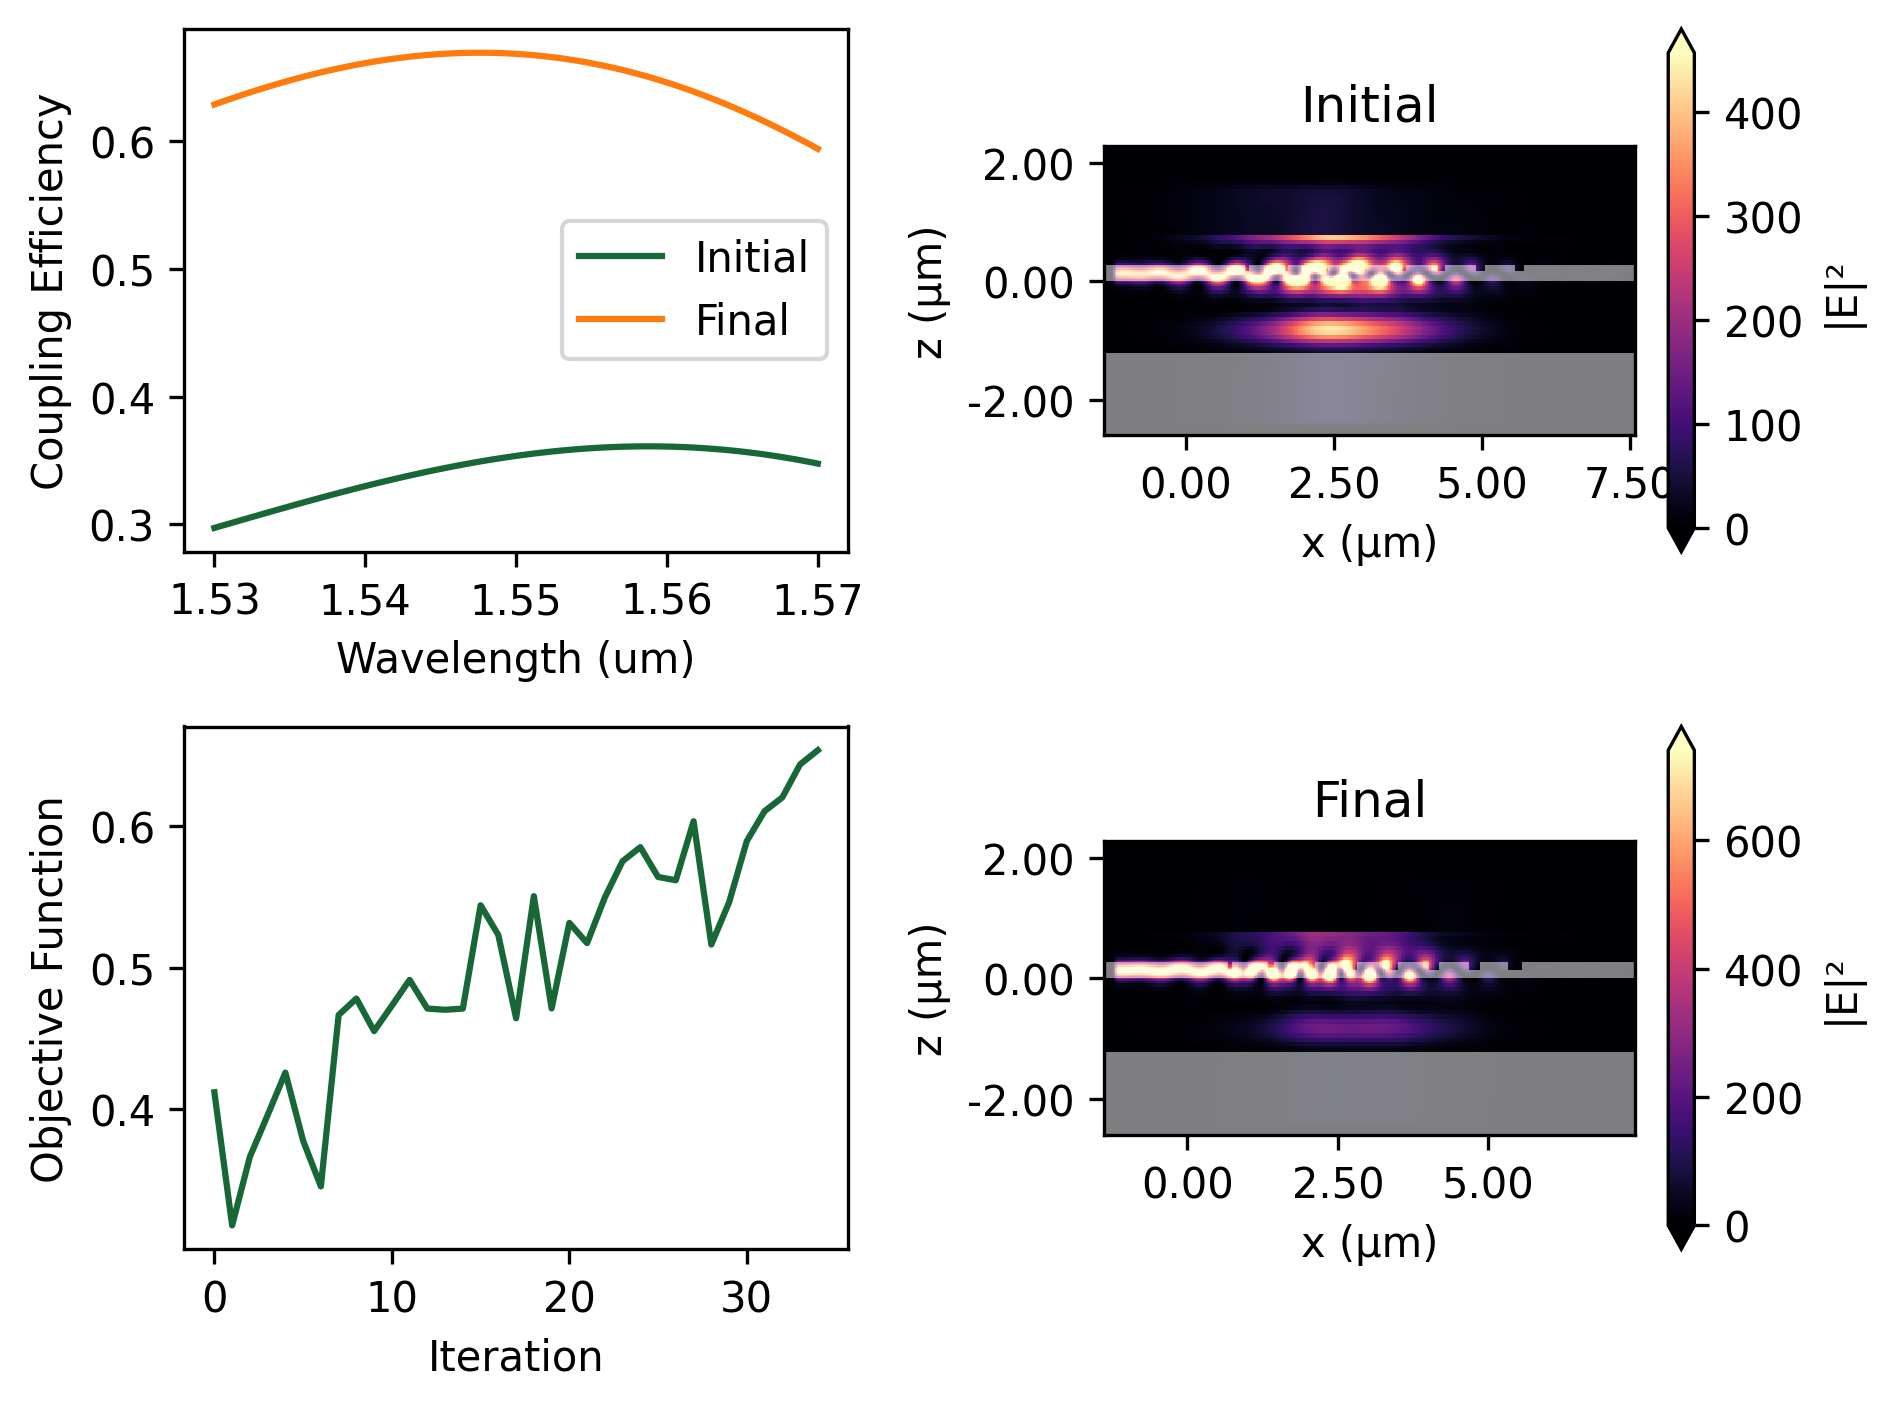

In [14]:
fig,ax = plt.subplots(2,2,dpi=300)

#plot the coupling efficiencies 
ax[0,0].plot(wl_range, ce_initial,label="Initial")
ax[0,0].plot(wl_range, ce_final,label="Final")
ax[0,0].set_xlabel("Wavelength (um)")
ax[0,0].set_ylabel("Coupling Efficiency")
ax[0,0].legend()

#plot the field monitors 
sim_data_initial.plot_field("field", "E", "abs^2", y=0, ax=ax[0,1],eps_alpha=0.5)
ax[0,1].set_title("Initial")
sim_data_final.plot_field("field", "E", "abs^2", y=0, ax=ax[1,1],eps_alpha=0.5)
ax[1,1].set_title("Final")

# plot the change in the objective function 
ax[1,0].plot(history["J"])
ax[1,0].set_xlabel("Iteration")
ax[1,0].set_ylabel("Objective Function")

plt.tight_layout()
plt.show()

# Conclusion 

We see that the stochastic optimization looks noisier than the previous optimization. This is expected since we are adding noise on each step. In addition, we see that additional iterations would likely lead to further improvments, but we will leave that for 3D. Finally, we see that we end up with a final design that has close to the same coupling effiency as the non-stochastic case, showing that stochastic gradient decent isn't considerably slower in this case.